## Hand-Scored Tasmanian Conditioning
This notebook exists to process hand-scored data from CCNL planarian conditioning projects that follow the protocls described in [James et al. (2025)](https://drive.google.com/file/d/1QFx8QHdXEkjAiJImBWZC_EdjRTzK_7hg/view?usp=drive_link). The data can be found [here](https://docs.google.com/spreadsheets/d/1M-xnRcIi3IS6-G30y5ylytBrqeMi3pINym3OKOTZn3c/edit?usp=sharing). This notebook is geared for reporting sums on a day.

I'm visually comparing my data to Sage's. It'll be plotting essentially the same structure of lines on a graph, color coded depending on whether they came from Sage or my data (manually scored turns and contractions per video).

## Things to review, confirm

- How does TP determine which trials to use? is there a csv or dictionary? Confirm it matches updated dict from LF NB 2

## Import packages, set filepaths, configure styles.

In [3]:
# ==============================================================================
# BLOCK 1: INITIALIZATION, CONFIGURATION, AND DATA LOADING
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats

# Define save path
SAVE_PATH = "../figures"
LOAD_ROOT = "../hand_scored_datasheets"

# SCORER CONFIGURATION DICTIONARY
# Flat keys for TC/TP and Turn/Contraction combinations
# Added *_dodge parameters for manual mean dodging (X-axis offset)
SCORER_CONFIG = {  
    'Zach': {
        'csv_path': LOAD_ROOT + "/Zach_Tasmdata_Tidy_All_Blind_Compiled.csv",
        'enabled': True,            
        'label_name': 'G. dorotocephala',       
        'tc_turn_color': '#1f4788ff', 'tc_turn_linestyle': '-',  'tc_turn_marker': 'o', 'tc_turn_dodge': 0,
        'tc_con_color': '#1f4788ff',  'tc_con_linestyle': '--',  'tc_con_marker': '^',  'tc_con_dodge': 0,
        'tp_turn_color': '#9e778aff', 'tp_turn_linestyle': '-',  'tp_turn_marker': 'o', 'tp_turn_dodge': -0.05,
        'tp_con_color': '#9e778aff',  'tp_con_linestyle': '--',  'tp_con_marker': '^',  'tp_con_dodge': 0.05,
        'markersize': 8, 'linewidth': 3, 'alpha': 1.0
    } 
}

# Load dataframes from csv for each scorer that is enabled
dfs = {}
for scorer, config in SCORER_CONFIG.items():
    if config['enabled']:
        try:
            dfs[scorer] = pd.read_csv(config['csv_path'])
            print(f"Loaded data for {scorer}")
        except FileNotFoundError:
            print(f"Warning: Could not find CSV for {scorer} at {config['csv_path']}")
        except Exception as e:
            print(f"Error loading {scorer}: {e}")

# Report unique runs and troupes
print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)

for scorer in dfs.keys():
    print(f"\n{scorer}'s data:")
    df = dfs[scorer]
    unique_runs = df['Run'].nunique()
    unique_troupes = df['Troupe'].nunique()
    print(f"\tUnique troupes: {sorted(df['Troupe'].unique())}")
    print(f"\tNumber of unique runs: {unique_runs}")
    print(f"\tNumber of unique troupes: {unique_troupes}")
    print(f"\tTroupes and runs agree? {unique_runs / unique_troupes == 8}.")

print("="*60 + "\n")

Loaded data for Zach

DATA SUMMARY

Zach's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.



## Define CSV analysis and graphing functions

In [4]:
# ==============================================================================
# BLOCK 2: FUNCTIONS (ANALYSIS, TABLES, GRAPHING)
# ==============================================================================

def analyze_raw_counts(df, troupes=None, days=None, verbose=True):
    behavioral_columns = [f"{behavior}_W{worm}" for behavior in ['CRturn', 'CRcon', 'UCRturn', 'UCRcon'] for worm in range(1, 7)]
    df_numeric = df.copy()
    for col in behavioral_columns:
        if col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0)
            
    if troupes is None: troupes = df_numeric['Troupe'].unique()
    if days is None: days = df_numeric['Day'].unique()
    
    filtered_df = df_numeric[df_numeric['Troupe'].isin(troupes) & df_numeric['Day'].isin(days)].copy()
    results = []
    
    for troupe in troupes:
        for day in days:
            subset = filtered_df[(filtered_df['Troupe'] == troupe) & (filtered_df['Day'] == day)]
            if len(subset) == 0: continue
            for worm_num in range(1, 7):
                worm_id = f"W{worm_num}"
                crturn_sum = subset[f'CRturn_{worm_id}'].sum()
                crcon_sum = subset[f'CRcon_{worm_id}'].sum()
                ucrturn_sum = subset[f'UCRturn_{worm_id}'].sum()
                ucrcon_sum = subset[f'UCRcon_{worm_id}'].sum()
                
                results.append({
                    'Troupe': troupe, 'Worm': worm_id, 'Day': day,
                    'CRturn': crturn_sum, 'CRcon': crcon_sum,
                    'UCRturn': ucrturn_sum, 'UCRcon': ucrcon_sum,
                    'UCRcombined': ucrcon_sum + ucrturn_sum,
                    'CRcombined': crcon_sum + crturn_sum
                })
                
    summary_df = pd.DataFrame(results)
    if len(summary_df) > 0:
        summary_df['Worm_sort'] = summary_df['Worm'].str.extract('(\d+)').astype(int)
        summary_df = summary_df.sort_values(['Troupe', 'Worm_sort', 'Day']).reset_index(drop=True)
        summary_df = summary_df.drop('Worm_sort', axis=1)
    return summary_df


def create_behavior_summary_table(scorer, tc_troupes=None, tp_troupes=None, behaviors=['CRturn'], days=[1, 4], error_type='SEM'):
    if scorer not in dfs: raise ValueError(f"Scorer '{scorer}' not found.")
    df = dfs[scorer]
    behavior_list = [behaviors] if isinstance(behaviors, str) else behaviors
    results = []
    
    for group_name, troupes in [('TC', tc_troupes), ('TP', tp_troupes)]:
        if troupes is None: continue
        troupes = [troupes] if isinstance(troupes, str) else troupes
        filtered_df = df[df['Troupe'].isin(troupes) & df['Day'].isin(days)].copy()
        
        if not filtered_df.empty:
            for behavior in behavior_list:
                behavioral_columns = [f"{behavior}_W{worm}" for worm in range(1, 7)]
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
                
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    if day_data.empty: continue
                    
                    all_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            all_values.extend(day_data[col].dropna().tolist())
                    
                    if all_values:
                        mean_val = np.mean(all_values)
                        sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                        error_val = stats.t.ppf(0.975, df=len(all_values)-1) * sem_val if error_type.upper() in ['95CI', 'CI'] else sem_val
                        error_label = '95% CI' if error_type.upper() in ['95CI', 'CI'] else 'SEM_Error'
                        
                        results.append({
                            'Scorer': scorer, 'Group': group_name, 'Behavior': behavior, 'Day': day,
                            'Mean': round(mean_val, 2), 'SEM': round(sem_val, 3),
                            f'{error_label}': round(error_val, 3), 'N': len(all_values),
                            'Std': round(np.std(all_values, ddof=1), 2)
                        })
                        
    summary_df = pd.DataFrame(results)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(['Behavior', 'Group', 'Day']).reset_index(drop=True)
    return summary_df


def create_day_comparison_lines(tc_troupes, tp_troupes, scorers=None, behaviors=['CRturn', 'CRcon'], 
                                days=[1, 4], figsize=(8, 6), SAVE=False, filename="", ylim=6.0, 
                                marker_size=None, line_width=None, show_legend=True, 
                                simplify_legend=True, error_type='SEM'):
    """
    Plots ALL specified behaviors and scorers onto a SINGLE graph.
    simplify_legend: If True, legends only show CC/PC rather than repeating for turns/contractions.
    """
    if scorers is None: scorers = list(dfs.keys())
    elif isinstance(scorers, str): scorers = [scorers]
    behavior_list = [behaviors] if isinstance(behaviors, str) else behaviors

    fig, ax = plt.subplots(figsize=figsize)  # Title here
    fig.suptitle('', fontsize=16, fontweight='bold')

    # Track what has been added to legend to keep it clean if simplify_legend is True
    added_to_legend = set()

    for scorer in scorers:
        df = dfs[scorer]
        config = SCORER_CONFIG[scorer]
        
        current_marker_size = marker_size if marker_size is not None else config['markersize']
        current_line_width = line_width if line_width is not None else config['linewidth']
        
        for current_behavior in behavior_list:
            is_turn = 'turn' in current_behavior.lower()
            beh_type = 'turn' if is_turn else 'con'

            for troupe_group, troupe_list in [('TC', tc_troupes), ('TP', tp_troupes)]:
                group = troupe_group.lower() # 'tc' or 'tp'
                
                # Fetch specific dictionary keys based on behavior and group
                color = config[f'{group}_{beh_type}_color']
                linestyle = config[f'{group}_{beh_type}_linestyle']
                marker = config[f'{group}_{beh_type}_marker']
                dodge = config.get(f'{group}_{beh_type}_dodge', 0.0) # <--- GET DODGE OFFSET

                filtered_df = df[df['Troupe'].isin(troupe_list) & df['Day'].isin(days)].copy()
                if filtered_df.empty: continue
                
                behavioral_columns = [f"{current_behavior}_W{worm}" for worm in range(1, 7)]
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')

                plot_days, plot_means, plot_errors = [], [], []
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    if day_data.empty: continue
                    
                    all_day_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            all_day_values.extend(day_data[col].dropna().tolist())
                    
                    if all_day_values:
                        day_mean = np.mean(all_day_values)
                        day_sem = np.std(all_day_values, ddof=1) / np.sqrt(len(all_day_values))
                        day_error = stats.t.ppf(0.975, df=len(all_day_values)-1) * day_sem if error_type.upper() in ['95CI', 'CI'] else day_sem
                        
                        plot_days.append(day)
                        plot_means.append(day_mean)
                        plot_errors.append(day_error)

                if plot_days:
                    # Apply the manual dodge to the X coordinates
                    plot_days_dodged = [d + dodge for d in plot_days]
                    
                    # Legend logic
                    display_group = "CC" if troupe_group == 'TC' else "PC"
                    
                    if simplify_legend:
                        legend_key = f"{scorer}_{display_group}"
                        if legend_key not in added_to_legend and is_turn: # Only add Turn lines to proxy the group
                            label = f"{config['label_name']} {display_group}"
                            added_to_legend.add(legend_key)
                        else:
                            label = "_nolegend_"
                    else:
                        label = f"{config['label_name']} {display_group} {current_behavior}"

                    # Plot using the dodged X coordinates
                    ax.errorbar(plot_days_dodged, plot_means, yerr=plot_errors,
                                color=color, linestyle=linestyle, linewidth=current_line_width,
                                marker=marker, markersize=current_marker_size, capsize=5,
                                alpha=config['alpha'], label=label)

    # Formatting the single axis
    behaviors_str = " & ".join(behavior_list)
    ax.set_ylabel(f'Behavior Score', fontsize=11, fontweight='bold')
    ax.set_xlabel('Day', fontsize=11, fontweight='bold')
    ax.set_title(f'', fontsize=12)

    ax.set_ylim(0, ylim if ylim is not None else 6.0)
    ax.set_xticks(days) # Keeps the bottom axis labels firmly pinned on the integers
    ax.set_xticklabels([f'Day {d}' for d in days])
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)
    
    if show_legend:
        ax.legend(loc='best', framealpha=0.9, fontsize=9)
        
    plt.tight_layout()
    
    if SAVE:
        if not filename:
            b_str = "_".join(behavior_list)
            d_str = "_".join(map(str, sorted(days)))
            s_str = "_".join(scorers)
            filename = f"Combined_Comparison_{s_str}_{b_str}_days{d_str}.svg"
        
        filepath = os.path.join(SAVE_PATH, filename)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {filepath}")
        plt.show()
    else:
        plt.show()

## Call and execute graphing functions.

Plot saved to: ../figures/../figures/Fig3B_Blind_HandScoring_Sc1.svg


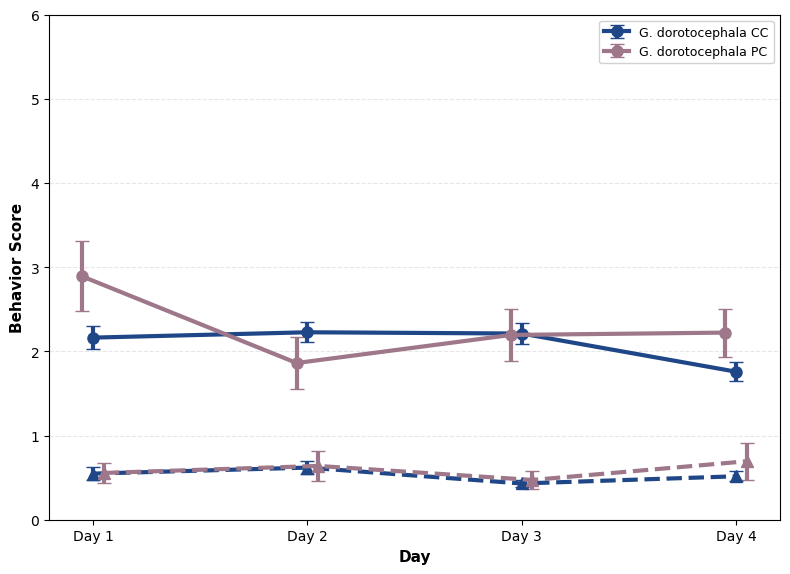

Combined plot generated successfully.


All Scorers Summary (TC vs TP):
   Scorer Group Behavior  Day  Mean    SEM  95% CI   N   Std
0    Zach    TC    CRcon    1  0.89  0.180   0.358  72  1.52
1    Zach    TC    CRcon    2  0.68  0.138   0.276  72  1.17
2    Zach    TC    CRcon    3  0.58  0.091   0.182  71  0.77
3    Zach    TC    CRcon    4  0.61  0.115   0.228  72  0.97
4    Zach    TP    CRcon    1  0.56  0.122   0.249  36  0.73
5    Zach    TP    CRcon    2  0.64  0.179   0.363  36  1.07
6    Zach    TP    CRcon    3  0.47  0.101   0.206  36  0.61
7    Zach    TP    CRcon    4  0.69  0.221   0.449  36  1.33
8    Zach    TC   CRturn    1  3.26  0.301   0.601  72  2.56
9    Zach    TC   CRturn    2  2.43  0.257   0.512  72  2.18
10   Zach    TC   CRturn    3  2.70  0.293   0.584  71  2.47
11   Zach    TC   CRturn    4  2.25  0.257   0.512  72  2.18
12   Zach    TP   CRturn    1  2.89  0.416   0.844  36  2.49
13   Zach    TP   CRturn    2  1.86  0.314   0.638  36  1.88
14   Zach    

In [5]:
# ==============================================================================
# BLOCK 3: EXECUTE GRAPHING AND SUMMARY TABLES
# ==============================================================================

# 1. Create the combined graph 
# NOTE: simplify_legend=True makes the legend only report "CC" and "PC" to keep it clean.
create_day_comparison_lines(
    tc_troupes=['TC-6', 'TC-7', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-MI-1'],
    tp_troupes=['TP-3', 'TP-4'],
    scorers=['Zach'],    # Just Zach for now
    behaviors=['CRturn', 'CRcon'],                # Putting both on the same graph
    days=[1, 2, 3, 4],
    figsize=(8, 6),
    ylim=6.0,                                     # Shared Y-axis limit
    error_type='SEM',
    simplify_legend=True,                         # Set to False if you want Turn/Con labeled individually
    SAVE=True,
    filename='../figures/Fig3B_Blind_HandScoring_Sc1.svg'
)

print("Combined plot generated successfully.\n")

# 2. Generate Behavior Summary Table
combined_summaries = []
for scorer_name in ['Zach']:
    summary = create_behavior_summary_table(
        scorer=scorer_name,
        tc_troupes=['TC-6', 'TC-7'],
        tp_troupes=['TP-3', 'TP-4'],
        behaviors=['CRturn', 'CRcon'],
        days=[1, 2, 3, 4],
        error_type='95CI'
    )
    combined_summaries.append(summary)

# Combine all scorer summaries into one dataframe
if combined_summaries:
    all_scorers_summary = pd.concat(combined_summaries, ignore_index=True)
    print("\nAll Scorers Summary (TC vs TP):")
    print(all_scorers_summary)

### NOTES AND TBD:
- Figure out why Fionn data has 68 and not 72 like everyone else
- Fix the double regions issue for that one video

In [4]:
# ==============================================================================
# BLOCK 4: TREND & GROUP DIFFERENCE STATISTICS
# Tests: (1) upward trend over days for TC and TP
#        (2) whether TC trend differs from TP (Day x Condition interaction)
# Behaviors tested: CRturn (turns) and CRcon (contractions)
# ==============================================================================
import numpy as np
from scipy import stats as sp_stats
import warnings

sep = "=" * 70

# ── Build per-worm, per-day long-format dataframe ────────────────────────────
TC_TROUPES = ['TC-6', 'TC-7', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-MI-1']
TP_TROUPES = ['TP-3', 'TP-4']
ALL_TROUPES = TC_TROUPES + TP_TROUPES
DAYS = [1, 2, 3, 4]

rows = []
for scorer_name, df_scorer in dfs.items():
    for troupe in ALL_TROUPES:
        tdata = df_scorer[df_scorer['Troupe'] == troupe]
        if tdata.empty:
            continue
        condition = 'TC' if troupe in TC_TROUPES else 'TP'
        for day in DAYS:
            ddata = tdata[tdata['Day'] == day]
            if ddata.empty:
                continue
            for worm_num in range(1, 7):
                wid = f"W{worm_num}"
                subject_key = f"{scorer_name}_{troupe}_{wid}"
                turn_col = f"CRturn_{wid}"
                con_col = f"CRcon_{wid}"
                turn_val = pd.to_numeric(ddata[turn_col], errors='coerce').sum() if turn_col in ddata.columns else np.nan
                con_val = pd.to_numeric(ddata[con_col], errors='coerce').sum() if con_col in ddata.columns else np.nan
                rows.append({
                    'Scorer': scorer_name, 'Troupe': troupe, 'Worm': wid,
                    'Subject': subject_key, 'Condition': condition,
                    'Day': day, 'CRturn': turn_val, 'CRcon': con_val
                })

df_stats = pd.DataFrame(rows)
df_stats = df_stats.dropna(subset=['CRturn', 'CRcon'], how='all')

print(f"Built stats dataframe: {len(df_stats)} rows, "
      f"{df_stats['Subject'].nunique()} unique subjects")
print(f"  TC subjects: {df_stats[df_stats['Condition']=='TC']['Subject'].nunique()}")
print(f"  TP subjects: {df_stats[df_stats['Condition']=='TP']['Subject'].nunique()}")

# ── Helper: per-subject slope t-test + Page's L ──────────────────────────────
def trend_test(df_sub, label, behavior):
    print(f"\n{sep}")
    print(f"  TREND: {label} -- {behavior}")
    print(sep)

    slopes, subj_labels = [], []
    for subj, sdata in df_sub.groupby('Subject'):
        day_vals = sdata.groupby('Day')[behavior].sum().dropna()
        if len(day_vals) >= 2:
            x = np.array(day_vals.index, dtype=float)
            y = np.array(day_vals.values, dtype=float)
            res = sp_stats.linregress(x, y)
            slopes.append(res.slope)
            subj_labels.append(subj)

    n = len(slopes)
    sarr = np.array(slopes)

    if n < 2:
        print(f"  Only {n} subject(s) -- cannot test.")
        return None

    mu, se = np.mean(sarr), np.std(sarr, ddof=1) / np.sqrt(n)
    tc = sp_stats.t.ppf(0.975, df=n-1)
    ci = (mu - tc*se, mu + tc*se)
    t_s, p2 = sp_stats.ttest_1samp(sarr, 0)
    p1_up = p2/2 if t_s > 0 else 1 - p2/2

    print(f"  Per-subject slope t-test (n = {n})")
    print(f"    Mean slope : {mu:+.4f} +/- {se:.4f} SEM")
    print(f"    95% CI     : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"    t({n-1}) = {t_s:+.3f}, p(two) = {p2:.4f}, p(one-sided up) = {p1_up:.4f}")
    if p1_up < 0.05 and mu > 0:
        print("    * SIGNIFICANT UPWARD TREND")
    else:
        print("    * No significant upward trend")

    # Page's L
    days_sorted = sorted(df_sub['Day'].dropna().unique())
    if len(days_sorted) >= 3:
        mat = []
        for subj, sdata in df_sub.groupby('Subject'):
            day_vals = sdata.groupby('Day')[behavior].sum()
            row = [day_vals.get(d, np.nan) for d in days_sorted]
            if all(not np.isnan(v) for v in row):
                mat.append(row)
        if len(mat) >= 2:
            try:
                pr = sp_stats.page_trend_test(np.array(mat, dtype=float))
                print(f"  Page's L (n={len(mat)}, k={len(days_sorted)}): L = {pr.statistic:.1f}, p = {pr.pvalue:.4f}")
                if pr.pvalue < 0.05:
                    print("    * SIGNIFICANT MONOTONE TREND (Page)")
                else:
                    print("    * No significant monotone trend (Page)")
            except Exception as e:
                print(f"  Page's L: error -- {e}")

    return {'slopes': sarr, 'labels': subj_labels, 'mean': mu, 'se': se, 'n': n,
            't': t_s, 'p_two': p2, 'p_one_up': p1_up}


# ── Run trend tests for each behavior ────────────────────────────────────────
df_tc = df_stats[df_stats['Condition'] == 'TC']
df_tp = df_stats[df_stats['Condition'] == 'TP']

results = {}
for behavior in ['CRturn', 'CRcon']:
    beh_label = 'Turns' if 'turn' in behavior else 'Contractions'
    results[f'TC_{behavior}'] = trend_test(df_tc, f"TC (conditioning) -- {beh_label}", behavior)
    results[f'TP_{behavior}'] = trend_test(df_tp, f"TP (pseudoconditioning) -- {beh_label}", behavior)

# ── TC vs TP comparison ──────────────────────────────────────────────────────
for behavior in ['CRturn', 'CRcon']:
    beh_label = 'Turns' if 'turn' in behavior else 'Contractions'
    print(f"\n{sep}")
    print(f"  TC vs TP COMPARISON -- {beh_label}")
    print(sep)

    tc_res = results.get(f'TC_{behavior}')
    tp_res = results.get(f'TP_{behavior}')

    if tc_res is None or tp_res is None:
        print("  Cannot compare -- insufficient data in one group")
        continue

    # Compare slopes (Day x Condition interaction equivalent)
    t_sl, p_sl = sp_stats.ttest_ind(tc_res['slopes'], tp_res['slopes'], equal_var=False)
    print(f"  Slope comparison (Welch's t):")
    print(f"    TC mean slope: {tc_res['mean']:+.4f} +/- {tc_res['se']:.4f}")
    print(f"    TP mean slope: {tp_res['mean']:+.4f} +/- {tp_res['se']:.4f}")
    print(f"    t = {t_sl:+.3f}, p = {p_sl:.4f}")
    if p_sl < 0.05:
        print("    * SIGNIFICANT DIFFERENCE in trends between TC and TP")
    else:
        print("    * No significant difference in trends")

    # Compare overall means
    tc_means = [df_tc[df_tc['Subject']==s][behavior].sum() / df_tc[df_tc['Subject']==s]['Day'].nunique()
                for s in df_tc['Subject'].unique()]
    tp_means = [df_tp[df_tp['Subject']==s][behavior].sum() / df_tp[df_tp['Subject']==s]['Day'].nunique()
                for s in df_tp['Subject'].unique()]
    tc_arr, tp_arr = np.array(tc_means), np.array(tp_means)
    t_m, p_m = sp_stats.ttest_ind(tc_arr, tp_arr, equal_var=False)
    d_cohen = (np.mean(tc_arr) - np.mean(tp_arr)) / np.sqrt((np.var(tc_arr,ddof=1) + np.var(tp_arr,ddof=1))/2)
    print(f"\n  Overall mean comparison:")
    print(f"    TC mean: {np.mean(tc_arr):.3f} +/- {np.std(tc_arr,ddof=1)/np.sqrt(len(tc_arr)):.3f} SEM")
    print(f"    TP mean: {np.mean(tp_arr):.3f} +/- {np.std(tp_arr,ddof=1)/np.sqrt(len(tp_arr)):.3f} SEM")
    print(f"    Welch's t = {t_m:+.3f}, p = {p_m:.4f}, Cohen's d = {d_cohen:+.3f}")

# ── LMM (if statsmodels available) ───────────────────────────────────────────
try:
    import statsmodels.formula.api as smf

    def fit_lmm_safe(formula, data, groups):
        model = smf.mixedlm(formula, data, groups=groups)
        for method in ["powell", "nm", "cg", "lbfgs"]:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    result = model.fit(reml=False, method=method, maxiter=1000)
                return result, method
            except Exception:
                continue
        print("    [!] All LMM optimizers failed; skipping")
        return None, None

    for behavior in ['CRturn', 'CRcon']:
        beh_label = 'Turns' if 'turn' in behavior else 'Contractions'
        print(f"\n{sep}")
        print(f"  LMM: {beh_label} ~ Day * Condition")
        print(sep)

        df_lmm = df_stats[['Subject', 'Condition', 'Day', behavior]].dropna().copy()
        df_lmm['y'] = df_lmm[behavior].astype(float)

        result, meth = fit_lmm_safe(
            "y ~ Day * C(Condition, Treatment('TC'))", df_lmm, df_lmm['Subject'])
        if result is not None:
            print(result.summary())
            print(f"  Optimizer: {meth}")
            params = result.params
            pvals = result.pvalues
            print(f"\n  Day (TC trend)        : coef = {params.get('Day', float('nan')):+.4f}, p = {pvals.get('Day', float('nan')):.4f}")
            cond_key = [k for k in params.index if 'Condition' in k and 'Day' not in k]
            inter_key = [k for k in params.index if 'Day' in k and 'Condition' in k]
            if cond_key:
                print(f"  Condition (TC vs TP)  : coef = {params[cond_key[0]]:+.4f}, p = {pvals[cond_key[0]]:.4f}")
            if inter_key:
                print(f"  Day x Condition      : coef = {params[inter_key[0]]:+.4f}, p = {pvals[inter_key[0]]:.4f}")

except (ImportError, AttributeError) as exc:
    print(f"\n{sep}")
    print(f"  statsmodels not usable ({type(exc).__name__}: {exc}) -- LMM skipped")
    print(sep)

print(f"\n{sep}")
print("  STATISTICS COMPLETE")
print(sep)

Built stats dataframe: 216 rows, 54 unique subjects
  TC subjects: 42
  TP subjects: 12

  TREND: TC (conditioning) -- Turns -- CRturn
  Per-subject slope t-test (n = 42)
    Mean slope : -0.3690 +/- 0.4625 SEM
    95% CI     : [-1.3032, +0.5651]
    t(41) = -0.798, p(two) = 0.4295, p(one-sided up) = 0.7852
    * No significant upward trend
  Page's L (n=42, k=4): L = 1046.0, p = 0.5847
    * No significant monotone trend (Page)

  TREND: TP (pseudoconditioning) -- Turns -- CRturn
  Per-subject slope t-test (n = 12)
    Mean slope : -0.5000 +/- 0.4487 SEM
    95% CI     : [-1.4877, +0.4877]
    t(11) = -1.114, p(two) = 0.2889, p(one-sided up) = 0.8555
    * No significant upward trend
  Page's L (n=12, k=4): L = 291.5, p = 0.8270
    * No significant monotone trend (Page)

  TREND: TC (conditioning) -- Contractions -- CRcon
  Per-subject slope t-test (n = 42)
    Mean slope : -0.0738 +/- 0.1618 SEM
    95% CI     : [-0.4006, +0.2530]
    t(41) = -0.456, p(two) = 0.6507, p(one-sided up)